# Scale-space & geometry-aware clustering

Two additions that cluster the `M ≪ N` CF microclusters using geometry the centroid heads ignore —
and that need **no `k`**:

- **`method="scale-space"`** — clusters the *modes* of the microcluster density
  `ρ_h(x) = Σ_j n_j exp(−‖x−μ_j‖²/2h²)`. As the bandwidth `h` grows, modes merge; the head sweeps
  `h` and keeps the labelling at the **most persistent** mode count (the widest plateau of the
  modes-vs-`log h` curve). No `k`, no bandwidth to guess.
- **geometry-aware Leiden (GeoBETULA)** — `covariance_weight` adds a log-Euclidean *shape* term and
  `tangent_weight` a Grassmann *orientation* term to the community-detection affinity, so communities
  agree in more than just position.

Both are honest about scope — the notes below say where each shines and where it does not.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score as ari

import betula_cluster

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

## 1 · Scale-space — let mode persistence choose the count

The same call, `method="scale-space"`, on blobs with a **different true count each time**. No
`n_clusters` is passed: the head reads the count off the density itself. On well-separated blobs it
recovers the count exactly.

,scale-space found,ARI
true k,,
2,2,1.000
4,4,1.000
8,8,0.997


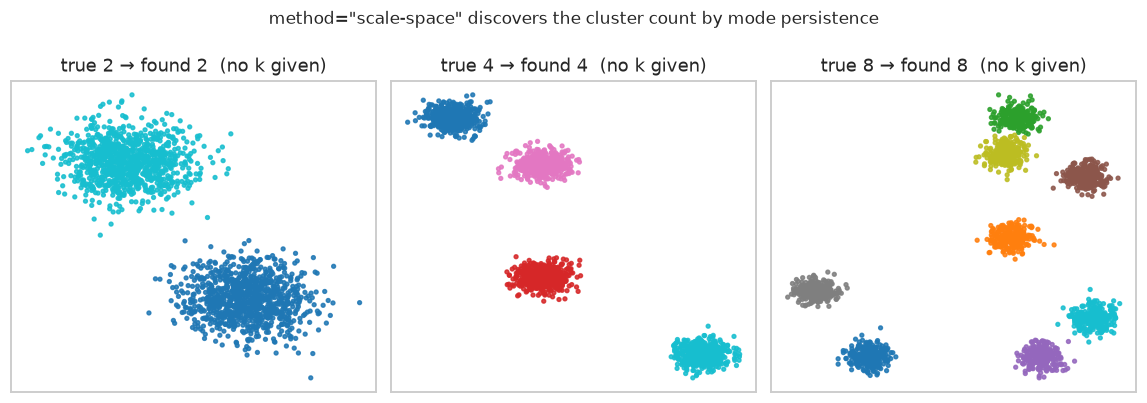

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
rows = []
for ax, k in zip(axes, (2, 4, 8)):
    X, y = make_blobs(n_samples=2000, centers=k, cluster_std=0.6, random_state=10 + k)
    labels = betula_cluster.fit_predict(X, method="scale-space", threshold=0.08, max_leaves=500, seed=0)
    found = len(set(labels))
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=6, alpha=0.85)
    ax.set(title=f"true {k} → found {found}  (no k given)", xticks=[], yticks=[])
    rows.append({"true k": k, "scale-space found": found, "ARI": round(ari(y, labels), 3)})
fig.suptitle('method="scale-space" discovers the cluster count by mode persistence', y=1.0)
fig.tight_layout()

# The results as a table.
pd.DataFrame(rows).set_index("true k")

### Scale-space vs the alternatives — what needs a `k`?

On one dataset, compared head-to-head: `scale-space` and `hdbscan` discover the count; `k-means`
must be told it. (`k-means` here is *given the correct* `k`, so it is a best case for it.)

In [3]:
Xc, yc = make_blobs(n_samples=1600, centers=3, cluster_std=0.65, random_state=13)
compare = []
for name, kw in [
    ("scale-space", dict(method="scale-space")),
    ("hdbscan", dict(method="hdbscan", min_cluster_size=25)),
    ("k-means (given k=3)", dict(method="kmeans", n_clusters=3)),
]:
    lab = betula_cluster.fit_predict(Xc, threshold=0.08, max_leaves=450, seed=0, **kw)
    compare.append(
        {
            "method": name,
            "needs k?": "no" if name != "k-means (given k=3)" else "yes",
            "clusters found": len({v for v in lab if v >= 0}),
            "ARI": round(ari(yc, lab), 3),
        }
    )
pd.DataFrame(compare).set_index("method")

,needs k?,clusters found,ARI
method,,,
scale-space,no,3,1.0
hdbscan,no,3,1.0
k-means (given k=3),yes,3,1.0


**When scale-space shines — and when it does not (honest scope).** A **prominence**-based mode merge
(collapse peaks separated by only a shallow density valley) keeps it robust across a **broad range of
counts** — 2 to ~8+ well-separated clusters — in **low-to-moderate dimension**, and unequal cluster
densities are fine. It is still not a universal replacement: in very high dimension the KDE flattens
(density concentrates — on 64-D `digits` every point merges into one mode), and heavily overlapping
clusters blur the modes. There, reach for `hdbscan` (variable density + noise) or `gmm` with BIC
(`n_clusters=0`).

## 2 · Geometry-aware Leiden (GeoBETULA)

`method="leiden"` builds a k-NN affinity over the microcluster centroids. With `feature="full"` two
optional terms make it geometry-aware:

- `covariance_weight` (β) — a **log-Euclidean** term `β·‖logΣ_i − logΣ_j‖²_F`, so two microclusters
  are neighbours only if they agree in *shape*;
- `tangent_weight` (γ) — a **Grassmann** term over each microcluster's principal subspace, so they
  agree in *orientation* (for crossing / adjacent manifolds).

We build three **anisotropic** clusters (elongated, differently oriented) and sweep
`covariance_weight`.

,communities,ARI
covariance_weight β,,
0.0,5,0.590
0.3,5,0.624
0.6,5,0.599


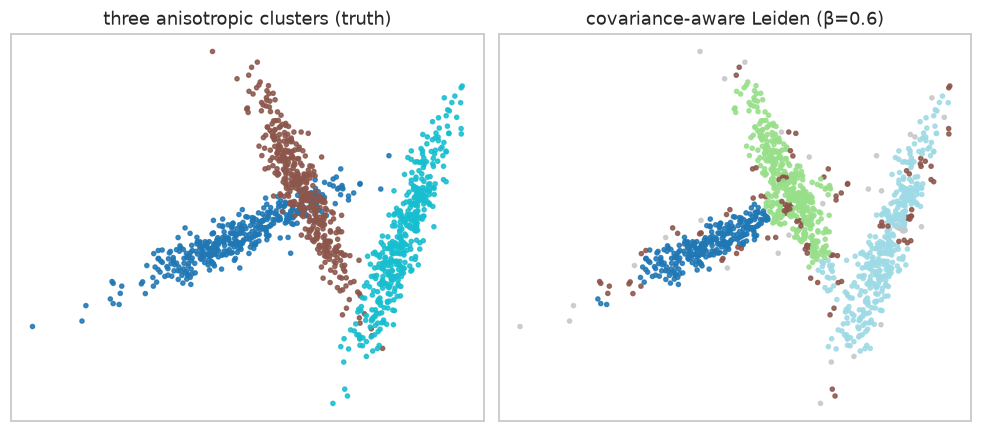

In [4]:
def aniso(n, center, angle_deg, sx, sy, rng):
    """`n` points from an axis-aligned Gaussian (std `sx`,`sy`) rotated by `angle_deg`, at `center`."""
    t = np.radians(angle_deg)
    rot = np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])
    return (rng.normal(0, 1, (n, 2)) * [sx, sy]) @ rot.T + center


rng = np.random.default_rng(0)
Xa = np.vstack(
    [
        aniso(400, [0, 0], 25, 3.0, 0.5, rng),
        aniso(400, [3, 2], 115, 3.0, 0.5, rng),
        aniso(400, [8, 0], 70, 3.0, 0.5, rng),
    ]
)
ya = np.r_[[0] * 400, [1] * 400, [2] * 400]

leiden_kw = dict(
    n_clusters=99, feature="full", method="leiden", resolution=0.3, threshold=0.25, max_leaves=300, seed=0
)
rows = []
best_labels = None
for cw in (0.0, 0.3, 0.6):
    lab = betula_cluster.fit_predict(Xa, covariance_weight=cw, **leiden_kw)
    rows.append({"covariance_weight β": cw, "communities": len(set(lab)), "ARI": round(ari(ya, lab), 3)})
    if cw == 0.6:
        best_labels = lab

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 4))
ax0.scatter(Xa[:, 0], Xa[:, 1], c=ya, cmap="tab10", s=7, alpha=0.85)
ax0.set(title="three anisotropic clusters (truth)", xticks=[], yticks=[])
ax1.scatter(Xa[:, 0], Xa[:, 1], c=best_labels, cmap="tab20", s=7, alpha=0.85)
ax1.set(title="covariance-aware Leiden (β=0.6)", xticks=[], yticks=[])
fig.tight_layout()

pd.DataFrame(rows).set_index("covariance_weight β")

**Read this honestly.** The shape term gives a small ARI lift for β>0 (here peaking near β=0.3) —
the communities track the anisotropic structure a little better. But Leiden still discovers *more*
communities than the three planted: on long, thin clusters its resolution splits each into segments,
and the geometry term nudges the graph without overriding that. So `covariance_weight` /
`tangent_weight` are **research knobs**: most useful when clusters differ more in **shape /
orientation** than in position (covariance descriptors, motion / time-series windows, crossing
manifolds), and best paired with a **low `resolution`**. For clean partitional structure, the
centroid heads (`kmeans` / `gmm`) remain the honest first choice. Full math:
[`docs/MATH.md`](../docs/MATH.md#geometry-aware-graph-geobetula-and-scale-space-modes).

**Takeaways.** `method="scale-space"` is a clean, `k`-free choice for a handful of density-separated
clusters — it reads the count off the data by mode persistence. Geometry-aware Leiden
(`covariance_weight` / `tangent_weight`, `feature="full"`) folds each microcluster's shape and
orientation into community detection — a modest, data-dependent refinement. Both run on the compressed
CF microclusters, so cost scales with the leaf count, not `N`. See the
[Usage guide](../docs/USAGE.md) and [`docs/FEATURES.md`](../docs/FEATURES.md).